<a href="https://colab.research.google.com/github/aienmii/LLM_app/blob/main/document_classifier_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import os, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from typing import Optional

warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

from google.colab import files
from IPython.display import display, HTML

print(' All imports successful!')

 All imports successful!


In [42]:
import kagglehub
import pandas as pd
import os



path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")



csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if not csv_files:
    print("Brak plików CSV w folderze!")
    print("   Sprawdzam podfoldery...")
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.csv'):
                print(f"   Znaleziono: {os.path.join(root, file)}")
                csv_files.append(os.path.join(root, file))
else:
    csv_files = [os.path.join(path, f) for f in csv_files]

print(f"\n Znalezione pliki CSV: {len(csv_files)}")

df_list = []
for csv_file in csv_files:
    print(f"   Wczytywanie: {os.path.basename(csv_file)}")
    try:
        temp_df = pd.read_csv(csv_file)
        df_list.append(temp_df)
        print(f"       {temp_df.shape}")
    except Exception as e:
        print(f"    Błąd: {e}")

if df_list:
    df = pd.concat(df_list, ignore_index=True)
else:
    print(" Nie udało się wczytać żadnego pliku CSV")

    for f in os.listdir(path):
        if f.endswith('.csv'):
            df = pd.read_csv(os.path.join(path, f))
            break

print(f"\nKształt danych: {df.shape}")
print(f"Kolumny: {df.columns.tolist()}")
print(f"\nPróbka danych:")
display(df.head(3))


text_col = None
for col in ['text', 'content', 'title', 'headline', 'article', 'description']:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    for col in df.columns:
        if df[col].dtype == 'object':
            text_col = col
            break

label_col = None
for col in ['label', 'category', 'class', 'topic', 'labels', 'categories']:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    for col in df.columns:
        if df[col].nunique() < 50 and df[col].nunique() > 1:
            label_col = col
            break

df['text'] = df[text_col].fillna('').astype(str)
df['label'] = df[label_col].fillna('').astype(str)


df = df.dropna(subset=['text', 'label'])
df = df[df['text'].str.len() > 20]

# Próbkuj do max 100 dokumentów
MAX_SAMPLES = 1500
if len(df) > MAX_SAMPLES:
    df = df.sample(n=MAX_SAMPLES, random_state=42)
    print(f" Próbkowano do {MAX_SAMPLES} dokumentów")

texts = df['text'].tolist()
labels = df['label'].tolist()





Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.

 Znalezione pliki CSV: 2
   Wczytywanie: train.csv
       (120000, 3)
   Wczytywanie: test.csv
       (7600, 3)

Kształt danych: (127600, 3)
Kolumny: ['Class Index', 'Title', 'Description']

Próbka danych:


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...


 Próbkowano do 1500 dokumentów


In [47]:
CLASSES = sorted(set(labels))
TEST_SIZE = 0.20
CV_FOLDS  = 5

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=TEST_SIZE, stratify=labels, random_state=42
)

def make_pipeline(clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=20_000,
            sublinear_tf=True,
            min_df=1,
        )),
        ('clf', clf),
    ])

PIPELINES = {
    'Naive Bayes'         : make_pipeline(MultinomialNB(alpha=0.1)),
    'LinearSVC'           : make_pipeline(LinearSVC(max_iter=2000, C=1.0)),
    'Logistic Regression' : make_pipeline(LogisticRegression(
                                max_iter=1000, C=5.0, solver='lbfgs')),
    'Random Forest'       : make_pipeline(RandomForestClassifier(
                                n_estimators=200, n_jobs=-1, random_state=42)),
}

results = {}
best_pipeline = None
best_name = ''
best_cv = -1.0

print(f'Training on {len(X_train)} docs | Testing on {len(X_test)} docs | CV={CV_FOLDS}\n')
print(f'{"Model":<25}  {"CV Mean":>8}  {"CV Std":>7}  {"Test Acc":>9}')
print('─' * 56)

for name, pipeline in PIPELINES.items():
    cv_scores = cross_val_score(pipeline, texts, labels, cv=CV_FOLDS, scoring='accuracy')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    results[name] = dict(cv_mean=cv_scores.mean(), cv_std=cv_scores.std(),
                         test_acc=test_acc, y_pred=y_pred)

    if cv_scores.mean() > best_cv:
        best_cv = cv_scores.mean()
        best_pipeline = pipeline
        best_name = name

    print(f'{name:<25}  {cv_scores.mean():>8.4f}  {cv_scores.std():>7.4f}  {test_acc:>9.4f}')


print(f'\n Best model: {best_name}  (CV accuracy = {best_cv:.4f})')

Training on 1200 docs | Testing on 300 docs | CV=5

Model                       CV Mean   CV Std   Test Acc
────────────────────────────────────────────────────────
Naive Bayes                  0.6973   0.0176     0.7400
LinearSVC                    0.6787   0.0230     0.6933
Logistic Regression          0.6633   0.0214     0.6833
Random Forest                0.5567   0.0202     0.5533
────────────────────────────────────────────────────────

 Best model: Naive Bayes  (CV accuracy = 0.6973)


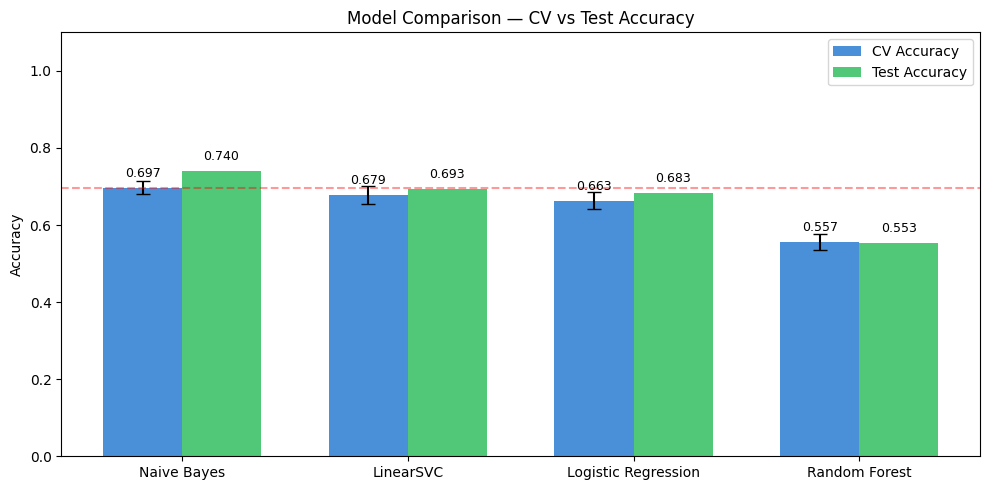

 Chart saved as model_comparison.png


In [48]:
model_names = list(results.keys())
cv_means = [results[m]['cv_mean'] for m in model_names]
cv_stds  = [results[m]['cv_std']  for m in model_names]
test_accs = [results[m]['test_acc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, cv_means, width, yerr=cv_stds,
               label='CV Accuracy', color='#4A90D9', capsize=5)
bars2 = ax.bar(x + width/2, test_accs, width,
               label='Test Accuracy', color='#50C878')

ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — CV vs Test Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(y=best_cv, color='red', linestyle='--', alpha=0.4, label=f'Best CV = {best_cv:.3f}')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print(' Chart saved as model_comparison.png')

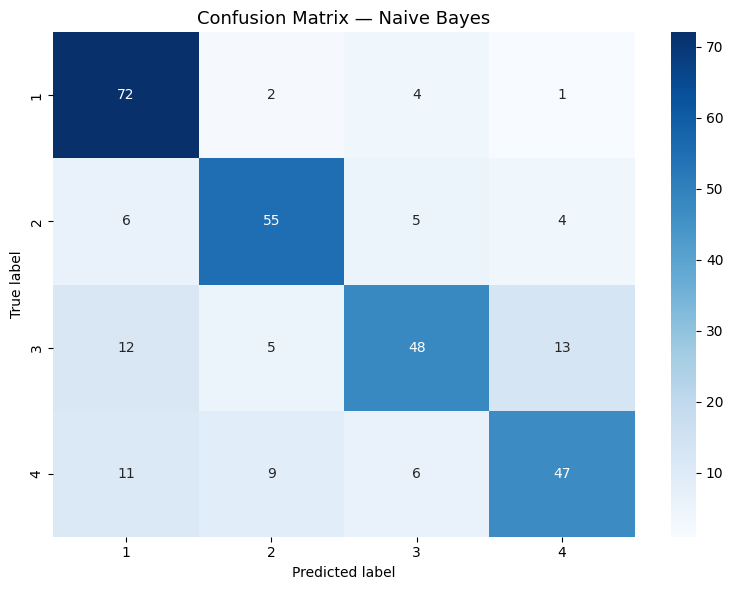

 Saved as confusion_matrix.png


In [49]:
best_pred = results[best_name]['y_pred']
cm = confusion_matrix(y_test, best_pred, labels=CLASSES)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print(' Saved as confusion_matrix.png')

In [50]:
print(f'Classification Report — {best_name}\n')
print(classification_report(y_test, best_pred, target_names=CLASSES))

Classification Report — Naive Bayes

              precision    recall  f1-score   support

           1       0.71      0.91      0.80        79
           2       0.77      0.79      0.78        70
           3       0.76      0.62      0.68        78
           4       0.72      0.64      0.68        73

    accuracy                           0.74       300
   macro avg       0.74      0.74      0.74       300
weighted avg       0.74      0.74      0.74       300



In [54]:
topic_mapping = {
    '1': 'Word',
    '2': 'Sport',
    '3': 'Bisness',
    '4': 'Tech and science'
}
def predict_documents(texts_to_predict: list, pipeline=best_pipeline) -> pd.DataFrame:
    """Predict topic and confidence for each document."""
    clf = pipeline.named_steps['clf']
    predicted = pipeline.predict(texts_to_predict)

    if hasattr(clf, 'predict_proba'):
        proba_matrix = pipeline.predict_proba(texts_to_predict)
        confidences = [round(float(np.max(p)), 4) for p in proba_matrix]
        all_scores  = [
            dict(zip(pipeline.classes_, [round(float(s), 4) for s in p]))
            for p in proba_matrix
        ]
    else:
        dec = pipeline.decision_function(texts_to_predict)
        if dec.ndim == 1:
            confidences = [round(float(abs(d)/(abs(d)+1)), 4) for d in dec]
            all_scores  = [{pred: c} for pred, c in zip(predicted, confidences)]
        else:
            softmax = lambda x: np.exp(x - x.max()) / np.exp(x - x.max()).sum()
            sm = [softmax(d) for d in dec]
            confidences = [round(float(s.max()), 4) for s in sm]
            all_scores  = [
                dict(zip(pipeline.classes_, [round(float(v), 4) for v in s]))
                for s in sm
            ]

    return pd.DataFrame({
        'document' : [t[:100] + '…' if len(t) > 100 else t for t in texts_to_predict],
        'topic'    : [topic_mapping.get(str(p), p) for p in predicted],
        'confidence': confidences,
        'all_scores': [{topic_mapping.get(str(k), k): v for k, v in score.items()}
                       for score in all_scores],
    })

# ── Test on unseen documents ───────────────────────────────────────
new_docs = [
    'The prime minister announced a new budget plan for the next fiscal year.',
    'Scientists have discovered a new treatment that may cure certain cancers.',
    'The local football club signed three new players ahead of the new season.',
    'Investors are turning to green bonds as a sustainable asset class.',
    'A new programming language claims to be faster and safer than C++.',
    'Nowe badania potwierdzają skuteczność szczepionki przeciwko grypie.',
    'Rząd planuje reformę systemu emerytalnego w przyszłym roku budżetowym.',
    'Rynek akcji odnotował spadki z powodu globalnych napięć handlowych.',
]

pred_df = predict_documents(new_docs)
scores_df = pd.json_normalize(pred_df['all_scores'])
final_df = pd.concat([pred_df[['document', 'topic', 'confidence']], scores_df], axis=1)
cols_to_style = ['confidence'] + list(scores_df.columns)
display(
    final_df.style
    .background_gradient(subset=cols_to_style, cmap='Greens')
    .format({col: '{:.1%}' for col in cols_to_style})
)


,document,topic,confidence,Word,Sport,Bisness,Tech and science
0,The prime minister announced a new budget plan for the next fiscal year.,Tech and science,58.7%,8.0%,13.5%,19.9%,58.7%
1,Scientists have discovered a new treatment that may cure certain cancers.,Tech and science,64.7%,8.4%,15.2%,11.6%,64.7%
2,The local football club signed three new players ahead of the new season.,Sport,72.8%,12.7%,72.8%,3.7%,10.8%
3,Investors are turning to green bonds as a sustainable asset class.,Word,43.8%,43.8%,30.9%,20.2%,5.1%
4,A new programming language claims to be faster and safer than C++.,Tech and science,57.1%,19.9%,5.6%,17.4%,57.1%
5,Nowe badania potwierdzają skuteczność szczepionki przeciwko grypie.,Word,26.4%,26.4%,23.3%,25.9%,24.3%
6,Rząd planuje reformę systemu emerytalnego w przyszłym roku budżetowym.,Word,26.4%,26.4%,23.3%,25.9%,24.3%
7,Rynek akcji odnotował spadki z powodu globalnych napięć handlowych.,Word,26.4%,26.4%,23.3%,25.9%,24.3%


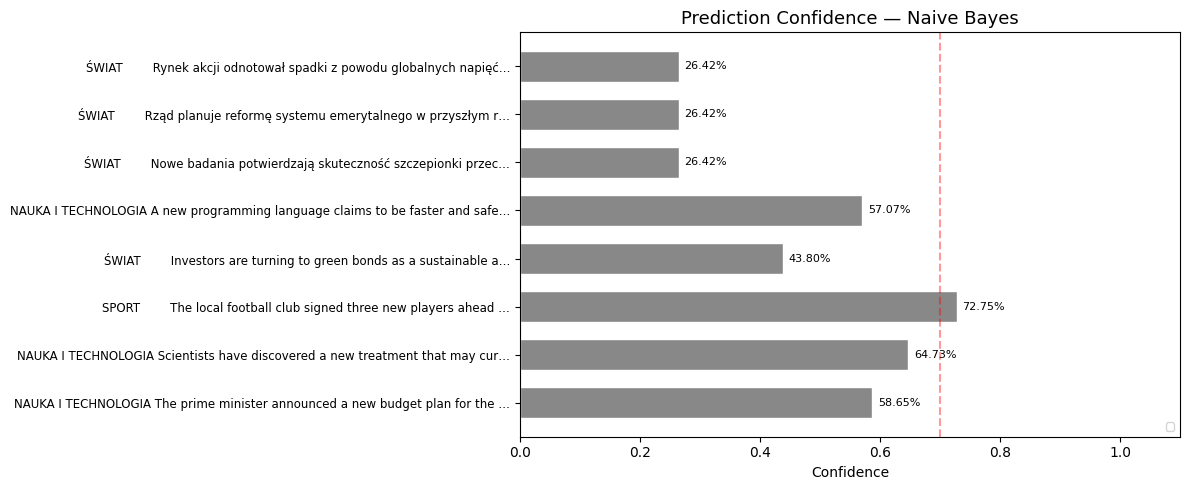

In [52]:
TOPIC_COLORS = {
    'technology': '#4A90D9', 'sports': '#50C878', 'health': '#FF6B6B',
    'finance': '#FFD700',    'politics': '#9B59B6', 'science': '#1ABC9C',
}

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [TOPIC_COLORS.get(t, '#888') for t in pred_df['topic']]
bars = ax.barh(range(len(pred_df)), pred_df['confidence'],
               color=bar_colors, edgecolor='white', height=0.65)

ax.set_yticks(range(len(pred_df)))
ax.set_yticklabels([f"{row.topic.upper():12} {row.document[:55]}…"
                    for row in pred_df.itertuples()], fontsize=8.5)
ax.set_xlabel('Confidence')
ax.set_xlim(0, 1.1)
ax.set_title(f'Prediction Confidence — {best_name}', fontsize=13)
ax.axvline(x=0.7, color='red', linestyle='--', alpha=0.4, label='Threshold 0.70')
ax.legend()

for bar, conf in zip(bars, pred_df['confidence']):
    ax.text(conf + 0.01, bar.get_y() + bar.get_height()/2,
            f'{conf:.2%}', va='center', fontsize=8)

patches = [mpatches.Patch(color=c, label=t)
           for t, c in TOPIC_COLORS.items() if t in pred_df['topic'].values]
ax.legend(handles=patches, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('prediction_confidence.png', dpi=150)
plt.show()

In [55]:

MY_DOCUMENT = "The government announced new policies affecting international trade and economic growth."


result = predict_documents([MY_DOCUMENT.strip()])
row = result.iloc[0]

row_scores = {topic_mapping.get(str(k), k): v for k, v in row['all_scores'].items()}

display(HTML(f"""
<div style="border:2px solid #4A90D9;border-radius:10px;padding:16px;font-family:monospace;max-width:650px">
  <b> Document:</b><br><i>{row['document']}</i><br><br>
  <b>Predicted topic:</b> <span style="color:#50C878;font-size:1.2em">{topic_mapping.get(str(row['topic']), row['topic']).upper()}</span><br>
  <b>Confidence:</b> <span style="color:#FFD700">{row['confidence']:.2%}</span><br><br>
  <b>All scores:</b><br>
  {''.join(
      f'<div style="display:flex;align-items:center;margin:2px 0">'
      f'<span style="width:140px">{t}</span>'
      f'<div style="background:#4A90D9;height:14px;width:{int(s*200)}px;border-radius:3px"></div>'
      f'<span style="margin-left:6px">{s:.4f}</span></div>'
      for t, s in sorted(row_scores.items(), key=lambda x: -x[1])
  )}
</div>
"""))